In [1]:
# ============================================================
# PHASE 5 — FORECASTING SETUP
# Create the training and test datasets for time-series forecasting
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path


# ============================================================
# Load the cleaned UPI dataset
# ============================================================

df = pd.read_csv(
    "../data/clean/upi_clean.csv",
    parse_dates=["date"]
)


# Keep the time series in chronological order
df = df.sort_values(
    "date"
).reset_index(drop=True)


# ============================================================
# Define the forecasting target
# Monthly UPI transaction volume will be forecast
# ============================================================

target = "volume_mn"


# ============================================================
# Reserve the latest 6 months as the test set
# April 2026 to September 2026
# ============================================================

test_months = 6

train = df.iloc[:-test_months].copy()
test = df.iloc[-test_months:].copy()


# ============================================================
# Validate the train/test split
# ============================================================

assert len(train) == 60
assert len(test) == 6

assert train["date"].max() < test["date"].min()


# ============================================================
# Display the forecasting periods
# ============================================================

print("Forecast target:", target)

print(
    "\nTraining period:",
    train["date"].min().date(),
    "to",
    train["date"].max().date()
)

print(
    "Training observations:",
    len(train)
)

print(
    "\nTest period:",
    test["date"].min().date(),
    "to",
    test["date"].max().date()
)

print(
    "Test observations:",
    len(test)
)


# ============================================================
# Display the actual test values
# These will be used later to evaluate the forecasts
# ============================================================

print("\nActual test-period transaction volume:")

display(
    test[
        ["date", target]
    ].round(2)
)

Forecast target: volume_mn

Training period: 2021-04-01 to 2026-03-01
Training observations: 60

Test period: 2026-04-01 to 2026-09-01
Test observations: 6

Actual test-period transaction volume:


C:\Users\Dell\AppData\Local\Temp\ipykernel_20628\3300074512.py:99: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(2)


,date,volume_mn
60,2026-04-01,22346.80
61,2026-05-01,23201.93
62,2026-06-01,22716.07
63,2026-07-01,23658.35
64,2026-08-01,24508.96
65,2026-09-01,24068.38


In [2]:
# ============================================================
# STEP 2 — Seasonal Naive Baseline
# Use the same month from the previous year as the forecast
# ============================================================


# Create a date-indexed training series
train_series = (
    train
    .set_index("date")[target]
)


# Shift each test date back by 12 months
seasonal_reference_dates = (
    test["date"]
    - pd.DateOffset(months=12)
)


# Get the previous year's same-month values
baseline_predictions = (
    train_series
    .reindex(seasonal_reference_dates)
    .values
)


# Store the baseline forecast
test = test.copy()

test["seasonal_naive"] = (
    baseline_predictions
)


# Validate that all baseline predictions exist
assert test["seasonal_naive"].notna().all()


# Display actual values and baseline forecasts
print("Seasonal Naive Baseline:")

display(
    test[
        [
            "date",
            target,
            "seasonal_naive"
        ]
    ].copy()
)


# Print the forecast reference period
print(
    "\nBaseline rule:"
)

print(
    "Each forecast uses the same calendar month "
    "from 12 months earlier."
)

Seasonal Naive Baseline:


,date,volume_mn,seasonal_naive
60,2026-04-01,22346.80,17893.42
61,2026-05-01,23201.93,18677.46
62,2026-06-01,22716.07,18395.01
63,2026-07-01,23658.35,19467.95
64,2026-08-01,24508.96,20008.31
65,2026-09-01,24068.38,19633.43



Baseline rule:
Each forecast uses the same calendar month from 12 months earlier.


In [3]:
# ============================================================
# STEP 3 — Holt-Winters Exponential Smoothing
# Learn the long-term trend and 12-month seasonal pattern
# from the 60-month training dataset
# ============================================================

from statsmodels.tsa.holtwinters import ExponentialSmoothing


# ============================================================
# Create a monthly time-series with a proper monthly frequency
# ============================================================

train_series = (
    train
    .set_index("date")[target]
    .asfreq("MS")
)


# ============================================================
# Fit the Holt-Winters model
# Additive trend + additive yearly seasonality
# ============================================================

hw_model = ExponentialSmoothing(
    train_series,
    trend="add",
    seasonal="add",
    seasonal_periods=12,
    initialization_method="estimated"
)


# Fit the model
hw_fit = hw_model.fit(
    optimized=True
)


# ============================================================
# Forecast the 6-month test period
# ============================================================

hw_forecast = hw_fit.forecast(
    steps=len(test)
)


# Match forecast dates with the actual test period
hw_forecast.index = test["date"].values


# Store Holt-Winters predictions
test["holt_winters"] = (
    hw_forecast.values
)


# ============================================================
# Validate that all forecasts were generated
# ============================================================

assert test["holt_winters"].notna().all()


# ============================================================
# Display actual values and Holt-Winters forecasts
# ============================================================

print("Holt-Winters Forecast:")

display(
    test[
        [
            "date",
            target,
            "seasonal_naive",
            "holt_winters"
        ]
    ].copy()
)


# ============================================================
# Display model information
# ============================================================

print(
    "\nModel:"
)

print(
    "Holt-Winters with additive trend "
    "and 12-month additive seasonality."
)

Holt-Winters Forecast:


,date,volume_mn,seasonal_naive,holt_winters
60,2026-04-01,22346.80,17893.42,22555.140665
61,2026-05-01,23201.93,18677.46,23056.744602
62,2026-06-01,22716.07,18395.01,23020.761463
63,2026-07-01,23658.35,19467.95,23674.648466
64,2026-08-01,24508.96,20008.31,24160.447440
65,2026-09-01,24068.38,19633.43,24181.292599



Model:
Holt-Winters with additive trend and 12-month additive seasonality.


In [4]:
# ============================================================
# STEP 4 — Trend + Seasonal Regression
# Model long-term time trend together with calendar-month effects
# as a robust third forecasting benchmark
# ============================================================

from sklearn.linear_model import LinearRegression


# ============================================================
# Remove any invalid SARIMA forecast from earlier attempts
# ============================================================

test = test.drop(
    columns=["sarima"],
    errors="ignore"
)


# ============================================================
# Prepare training features
# Time index captures the long-term growth trend
# Month dummies capture recurring monthly seasonality
# ============================================================

train_model = train.copy()

train_model["time_index"] = np.arange(
    len(train_model)
)


train_month_dummies = pd.get_dummies(
    train_model["month_number"],
    prefix="month",
    drop_first=True,
    dtype=int
)


X_train = pd.concat(
    [
        train_model[["time_index"]],
        train_month_dummies
    ],
    axis=1
)

y_train = train_model[target]


# ============================================================
# Prepare test-period features
# ============================================================

test_model = test.copy()

test_model["time_index"] = np.arange(
    len(train),
    len(train) + len(test)
)


test_month_dummies = pd.get_dummies(
    test_model["month_number"],
    prefix="month",
    drop_first=True,
    dtype=int
)


# Make test features match training features exactly
test_month_dummies = test_month_dummies.reindex(
    columns=train_month_dummies.columns,
    fill_value=0
)


X_test = pd.concat(
    [
        test_model[["time_index"]],
        test_month_dummies
    ],
    axis=1
)


# ============================================================
# Fit the trend + seasonal regression model
# ============================================================

trend_seasonal_model = LinearRegression()

trend_seasonal_model.fit(
    X_train,
    y_train
)


# ============================================================
# Generate the 6-month test forecast
# ============================================================

trend_seasonal_forecast = (
    trend_seasonal_model.predict(X_test)
)


# Store predictions
test["trend_seasonal"] = (
    trend_seasonal_forecast
)


# ============================================================
# Validate the forecast
# ============================================================

assert test["trend_seasonal"].notna().all()
assert (test["trend_seasonal"] > 0).all()


# ============================================================
# Display the forecast comparison
# ============================================================

print("Trend + Seasonal Regression Forecast:")

display(
    test[
        [
            "date",
            target,
            "seasonal_naive",
            "holt_winters",
            "trend_seasonal"
        ]
    ].copy()
)


# ============================================================
# Display model description
# ============================================================

print("\nModel:")
print(
    "Linear trend + calendar-month seasonal effects"
)


print(
    "\nFeatures used:",
    X_train.shape[1]
)

Trend + Seasonal Regression Forecast:


,date,volume_mn,seasonal_naive,holt_winters,trend_seasonal
60,2026-04-01,22346.80,17893.42,22555.140665,21962.804625
61,2026-05-01,23201.93,18677.46,23056.744602,22459.991500
62,2026-06-01,22716.07,18395.01,23020.761463,22392.433500
63,2026-07-01,23658.35,19467.95,23674.648466,23016.205500
64,2026-08-01,24508.96,20008.31,24160.447440,23473.851500
65,2026-09-01,24068.38,19633.43,24181.292599,23468.533500



Model:
Linear trend + calendar-month seasonal effects

Features used: 12


In [5]:
# ============================================================
# STEP 5 — Walk-Forward Backtesting
# Test each forecasting model on multiple historical 6-month
# periods without using future information
# ============================================================

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.linear_model import LinearRegression


# ============================================================
# Define the forecast horizon
# Each historical test window contains 6 months
# ============================================================

horizon = 6


# Use at least 36 months of historical data before forecasting
min_train_size = 36


# Keep the final 6-month holdout period untouched
final_test_start = len(df) - horizon


# Backtest origins must finish before the final holdout
max_origin = final_test_start - horizon


# Store all backtest predictions
backtest_results = []


# ============================================================
# Helper function for Trend + Seasonal Regression
# ============================================================

def forecast_trend_seasonal(train_data, future_data):
    """
    Forecast using a linear time trend plus calendar-month effects.
    """

    train_model = train_data.copy()

    future_model = future_data.copy()


    # Create a sequential time index
    train_model["time_index"] = np.arange(
        len(train_model)
    )

    future_model["time_index"] = np.arange(
        len(train_model),
        len(train_model) + len(future_model)
    )


    # Create calendar-month dummy variables
    train_dummies = pd.get_dummies(
        train_model["month_number"],
        prefix="month",
        drop_first=True,
        dtype=int
    )


    future_dummies = pd.get_dummies(
        future_model["month_number"],
        prefix="month",
        drop_first=True,
        dtype=int
    )


    # Match future columns to training columns
    future_dummies = future_dummies.reindex(
        columns=train_dummies.columns,
        fill_value=0
    )


    # Create model matrices
    X_train = pd.concat(
        [
            train_model[["time_index"]],
            train_dummies
        ],
        axis=1
    )


    X_future = pd.concat(
        [
            future_model[["time_index"]],
            future_dummies
        ],
        axis=1
    )


    # Fit the regression model
    model = LinearRegression()

    model.fit(
        X_train,
        train_model[target]
    )


    # Generate forecasts
    predictions = model.predict(
        X_future
    )


    return predictions


# ============================================================
# Run walk-forward backtesting across historical periods
# ============================================================

for origin in range(
    min_train_size,
    max_origin + 1
):

    # Historical training window
    fold_train = df.iloc[
        :origin
    ].copy()


    # Six-month future evaluation window
    fold_test = df.iloc[
        origin:origin + horizon
    ].copy()


    # --------------------------------------------------------
    # Model 1 — Seasonal Naive
    # --------------------------------------------------------

    fold_train_series = (
        fold_train
        .set_index("date")[target]
    )


    seasonal_reference_dates = (
        fold_test["date"]
        - pd.DateOffset(months=12)
    )


    seasonal_naive_forecast = (
        fold_train_series
        .reindex(seasonal_reference_dates)
        .values
    )


    # --------------------------------------------------------
    # Model 2 — Holt-Winters
    # --------------------------------------------------------

    hw_series = (
        fold_train
        .set_index("date")[target]
        .asfreq("MS")
    )


    hw_model = ExponentialSmoothing(
        hw_series,
        trend="add",
        seasonal="add",
        seasonal_periods=12,
        initialization_method="estimated"
    )


    hw_fit = hw_model.fit(
        optimized=True
    )


    hw_forecast = (
        hw_fit
        .forecast(horizon)
        .values
    )


    # --------------------------------------------------------
    # Model 3 — Trend + Seasonal Regression
    # --------------------------------------------------------

    trend_seasonal_forecast = (
        forecast_trend_seasonal(
            fold_train,
            fold_test
        )
    )


    # --------------------------------------------------------
    # Store all predictions
    # --------------------------------------------------------

    for i in range(horizon):

        backtest_results.append(
            {
                "origin": fold_train["date"].iloc[-1],
                "date": fold_test["date"].iloc[i],
                "actual": fold_test[target].iloc[i],
                "seasonal_naive": seasonal_naive_forecast[i],
                "holt_winters": hw_forecast[i],
                "trend_seasonal": trend_seasonal_forecast[i]
            }
        )


# ============================================================
# Convert backtest results into a dataframe
# ============================================================

backtest_df = pd.DataFrame(
    backtest_results
)


# ============================================================
# Validate the backtest
# ============================================================

assert not backtest_df.empty

assert backtest_df[
    [
        "seasonal_naive",
        "holt_winters",
        "trend_seasonal"
    ]
].notna().all().all()


# Make sure final test months were not used in backtesting
assert (
    backtest_df["date"].max()
    < test["date"].min()
)


# ============================================================
# Display the backtest summary
# ============================================================

print(
    "Backtest folds:",
    backtest_df["origin"].nunique()
)

print(
    "Backtest observations:",
    len(backtest_df)
)

print(
    "\nBacktest period:",
    backtest_df["date"].min().date(),
    "to",
    backtest_df["date"].max().date()
)


# Display the first few backtest predictions
print(
    "\nSample backtest predictions:"
)

display(
    backtest_df.head(10)
)

Backtest folds: 19
Backtest observations: 114

Backtest period: 2024-04-01 to 2026-03-01

Sample backtest predictions:


,origin,date,actual,seasonal_naive,holt_winters,trend_seasonal
0,2024-03-01,2024-04-01,13303.99,8863.26,13650.426576,12721.223125
1,2024-03-01,2024-05-01,14035.84,9415.19,14075.573116,13066.845000
2,2024-03-01,2024-06-01,13885.14,9335.06,14254.065466,13098.631667
3,2024-03-01,2024-07-01,14435.55,9964.61,14893.428104,13597.135000
4,2024-03-01,2024-08-01,14963.05,10586.02,15436.223632,14003.925000
5,2024-03-01,2024-09-01,15041.75,10555.69,15656.711083,14093.788333
6,2024-04-01,2024-05-01,14035.84,9415.19,13641.760665,13054.802716
7,2024-04-01,2024-06-01,13885.14,9335.06,13672.833601,13155.447407
8,2024-04-01,2024-07-01,14435.55,9964.61,14170.282633,13653.950741
9,2024-04-01,2024-08-01,14963.05,10586.02,14576.277550,14060.740741


In [6]:
# ============================================================
# STEP 6 — Forecast Accuracy Metrics
# Compare model accuracy using MAPE, MAE, and RMSE
# Lower values indicate smaller forecasting errors
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error


# ============================================================
# Define a safe MAPE function
# ============================================================

def calculate_mape(actual, predicted):
    """
    Calculate Mean Absolute Percentage Error.
    """

    actual = np.asarray(actual)
    predicted = np.asarray(predicted)

    mask = actual != 0

    return (
        np.mean(
            np.abs(
                (actual[mask] - predicted[mask])
                / actual[mask]
            )
        ) * 100
    )


# ============================================================
# Define the models to evaluate
# ============================================================

models = {
    "Seasonal Naive": "seasonal_naive",
    "Holt-Winters": "holt_winters",
    "Trend + Seasonal": "trend_seasonal"
}


# ============================================================
# Calculate accuracy metrics for each model
# ============================================================

metrics = []


for model_name, column in models.items():

    actual = backtest_df["actual"]
    predicted = backtest_df[column]


    # Calculate MAPE
    mape = calculate_mape(
        actual,
        predicted
    )


    # Calculate MAE
    mae = mean_absolute_error(
        actual,
        predicted
    )


    # Calculate RMSE
    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )


    metrics.append(
        {
            "model": model_name,
            "MAPE_pct": mape,
            "MAE_mn": mae,
            "RMSE_mn": rmse
        }
    )


# ============================================================
# Create the model performance table
# ============================================================

metrics_df = pd.DataFrame(
    metrics
)


# Round the metrics for readability
metrics_df[
    ["MAPE_pct", "MAE_mn", "RMSE_mn"]
] = metrics_df[
    ["MAPE_pct", "MAE_mn", "RMSE_mn"]
].round(2)


# ============================================================
# Display model performance
# ============================================================

print("Walk-Forward Backtest Performance:")

display(
    metrics_df
)


# ============================================================
# Validate that all metrics are finite
# ============================================================

assert np.isfinite(
    metrics_df[
        ["MAPE_pct", "MAE_mn", "RMSE_mn"]
    ].values
).all()


print(
    "\nMetric calculation: PASS"
)

print(
    "\nLower MAPE, MAE, and RMSE indicate smaller "
    "forecasting errors."
)

Walk-Forward Backtest Performance:


,model,MAPE_pct,MAE_mn,RMSE_mn
0,Seasonal Naive,26.32,4627.20,4637.72
1,Holt-Winters,1.92,332.49,427.55
2,Trend + Seasonal,5.49,977.91,1036.00



Metric calculation: PASS

Lower MAPE, MAE, and RMSE indicate smaller forecasting errors.


In [7]:
# ============================================================
# STEP 7 — Final Holdout Evaluation
# Evaluate all usable models on the untouched Apr-Sep 2026 data
# ============================================================

# Reuse the safe MAPE function from Step 6
final_metrics = []


# Define the models to evaluate
models = {
    "Seasonal Naive": "seasonal_naive",
    "Holt-Winters": "holt_winters",
    "Trend + Seasonal": "trend_seasonal"
}


# ============================================================
# Calculate final holdout metrics
# ============================================================

for model_name, column in models.items():

    actual = test[target]
    predicted = test[column]


    # Calculate MAPE
    mape = calculate_mape(
        actual,
        predicted
    )


    # Calculate MAE
    mae = mean_absolute_error(
        actual,
        predicted
    )


    # Calculate RMSE
    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )


    # Calculate average forecast bias
    bias = np.mean(
        predicted - actual
    )


    final_metrics.append(
        {
            "model": model_name,
            "MAPE_pct": mape,
            "MAE_mn": mae,
            "RMSE_mn": rmse,
            "Bias_mn": bias
        }
    )


# ============================================================
# Create final evaluation table
# ============================================================

final_metrics_df = pd.DataFrame(
    final_metrics
)


# Round numerical metrics
final_metrics_df[
    [
        "MAPE_pct",
        "MAE_mn",
        "RMSE_mn",
        "Bias_mn"
    ]
] = final_metrics_df[
    [
        "MAPE_pct",
        "MAE_mn",
        "RMSE_mn",
        "Bias_mn"
    ]
].round(2)


# ============================================================
# Display final holdout performance
# ============================================================

print(
    "Final Holdout Performance (Apr-Sep 2026):"
)

display(
    final_metrics_df
)


# ============================================================
# Display actual vs forecast values
# ============================================================

print(
    "\nFinal Holdout Forecasts:"
)

display(
    test[
        [
            "date",
            target,
            "seasonal_naive",
            "holt_winters",
            "trend_seasonal"
        ]
    ].round(2)
)


# ============================================================
# Validate final metrics
# ============================================================

assert np.isfinite(
    final_metrics_df[
        [
            "MAPE_pct",
            "MAE_mn",
            "RMSE_mn",
            "Bias_mn"
        ]
    ].values
).all()


print(
    "\nFinal holdout evaluation: PASS"
)

Final Holdout Performance (Apr-Sep 2026):


,model,MAPE_pct,MAE_mn,RMSE_mn,Bias_mn
0,Seasonal Naive,18.83,4404.15,4405.66,-4404.15
1,Holt-Winters,0.81,189.32,220.53,24.76
2,Trend + Seasonal,2.63,621.11,664.11,-621.11



Final Holdout Forecasts:


C:\Users\Dell\AppData\Local\Temp\ipykernel_20628\1195695672.py:125: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(2)


,date,volume_mn,seasonal_naive,holt_winters,trend_seasonal
60,2026-04-01,22346.80,17893.42,22555.14,21962.80
61,2026-05-01,23201.93,18677.46,23056.74,22459.99
62,2026-06-01,22716.07,18395.01,23020.76,22392.43
63,2026-07-01,23658.35,19467.95,23674.65,23016.21
64,2026-08-01,24508.96,20008.31,24160.45,23473.85
65,2026-09-01,24068.38,19633.43,24181.29,23468.53



Final holdout evaluation: PASS


C:\Users\Dell\Downloads\upi-analysis\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Final model converged: True

Final UPI Transaction Volume Forecast:


,date,forecast_volume_mn,lower_95_pct,upper_95_pct
0,2026-10-01,25260.56,24679.70,25790.32
1,2026-11-01,25003.62,24410.76,25593.00
2,2026-12-01,25821.43,25176.12,26518.31
3,2027-01-01,25961.77,25229.08,26834.75
4,2027-02-01,25415.53,24520.82,26520.67
5,2027-03-01,26889.49,25812.82,28301.26



Average forecast volume: 25,725 Mn
Oct 2026 forecast: 25,261 Mn
Mar 2027 forecast: 26,889 Mn
Forecast change from Oct 2026 to Mar 2027: +6.4%


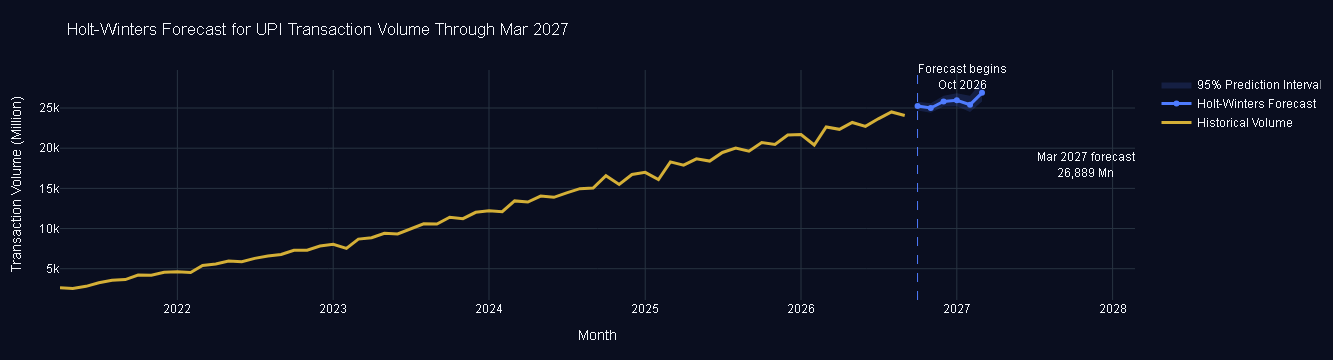


Final forecast outputs saved successfully.
PNG:         ..\images\09_upi_forecast.png
HTML:        ..\dashboard\charts\09_upi_forecast.html
CSV:         ..\data\clean\upi_forecast.csv
Documentation: ..\docs\forecast_findings.md


In [12]:
# Phase 5 — Step 8: Fit the final Holt-Winters model, generate the forecast, estimate prediction intervals, and save outputs

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pathlib import Path

# Set reproducible random seed for prediction interval simulation
SEED = 42
np.random.seed(SEED)

# Define project paths
BASE_DIR = Path("..")
DATA_PATH = BASE_DIR / "data" / "clean" / "upi_clean.csv"
IMAGE_DIR = BASE_DIR / "images"
CHART_DIR = BASE_DIR / "dashboard" / "charts"
DOCS_DIR = BASE_DIR / "docs"

# Create output directories if they do not already exist
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)
DOCS_DIR.mkdir(parents=True, exist_ok=True)

# Load the cleaned UPI dataset
df = pd.read_csv(DATA_PATH, parse_dates=["date"])

# Sort the data chronologically and prepare the target series
df = df.sort_values("date").reset_index(drop=True)
y = df.set_index("date")["volume_mn"].astype(float)

# Create the final Holt-Winters model using all available observations
final_hw_model = ExponentialSmoothing(
    y,
    trend="add",
    seasonal="add",
    seasonal_periods=12,
    initialization_method="estimated"
)

# Fit the final model on the complete dataset
final_hw_fit = final_hw_model.fit(optimized=True)

# Define the six-month future forecast horizon
forecast_dates = pd.date_range(
    start=y.index.max() + pd.offsets.MonthBegin(1),
    periods=6,
    freq="MS"
)

# Generate the point forecast for the next six months
forecast_values = final_hw_fit.forecast(6)

# Convert the forecast to a clean Series with the correct dates
forecast_values = pd.Series(
    np.asarray(forecast_values, dtype=float),
    index=forecast_dates,
    name="forecast_volume_mn"
)

# Simulate future paths to estimate a 95% prediction interval
simulated_paths = final_hw_fit.simulate(
    nsimulations=6,
    repetitions=5000,
    error="add",
    random_errors="bootstrap",
    anchor="end",
    rng=np.random.default_rng(SEED)
)

# Convert simulation output to a NumPy array
simulated_paths = np.asarray(simulated_paths, dtype=float)

# Make sure the simulation dimensions are rows = forecast months and columns = simulations
if simulated_paths.shape[0] != 6 and simulated_paths.shape[1] == 6:
    simulated_paths = simulated_paths.T

# Calculate lower and upper 95% prediction bounds
lower_95 = np.percentile(simulated_paths, 2.5, axis=1)
upper_95 = np.percentile(simulated_paths, 97.5, axis=1)

# Build the final forecast DataFrame
forecast_df = pd.DataFrame({
    "date": forecast_dates,
    "forecast_volume_mn": forecast_values.values,
    "lower_95_pct": lower_95,
    "upper_95_pct": upper_95
})

# Round forecast values for clean display
forecast_display = forecast_df.copy()

forecast_display["forecast_volume_mn"] = (
    forecast_display["forecast_volume_mn"].round(2)
)

forecast_display["lower_95_pct"] = (
    forecast_display["lower_95_pct"].round(2)
)

forecast_display["upper_95_pct"] = (
    forecast_display["upper_95_pct"].round(2)
)

# Display the final forecast table
print("Final model converged:", final_hw_fit.mle_retvals.get("converged", True))

print("\nFinal UPI Transaction Volume Forecast:")
display(forecast_display)

# Calculate summary forecast statistics
average_forecast = forecast_df["forecast_volume_mn"].mean()
oct_forecast = forecast_df.loc[
    forecast_df["date"] == pd.Timestamp("2026-10-01"),
    "forecast_volume_mn"
].iloc[0]
mar_forecast = forecast_df.loc[
    forecast_df["date"] == pd.Timestamp("2027-03-01"),
    "forecast_volume_mn"
].iloc[0]

forecast_change_pct = ((mar_forecast / oct_forecast) - 1) * 100

print(f"\nAverage forecast volume: {average_forecast:,.0f} Mn")
print(f"Oct 2026 forecast: {oct_forecast:,.0f} Mn")
print(f"Mar 2027 forecast: {mar_forecast:,.0f} Mn")
print(f"Forecast change from Oct 2026 to Mar 2027: {forecast_change_pct:+.1f}%")

# Combine historical and forecast data for charting
historical_dates = y.index
historical_values = y.values

# Create the forecast chart
fig = go.Figure()

# Plot historical transaction volume
fig.add_trace(
    go.Scatter(
        x=historical_dates,
        y=historical_values,
        mode="lines",
        name="Historical Volume",
        line=dict(
            color="#D4AF37",
            width=3
        )
    )
)

# Plot the Holt-Winters forecast
fig.add_trace(
    go.Scatter(
        x=forecast_df["date"],
        y=forecast_df["forecast_volume_mn"],
        mode="lines+markers",
        name="Holt-Winters Forecast",
        line=dict(
            color="#4F7CFF",
            width=3
        ),
        marker=dict(size=6)
    )
)

# Plot the upper prediction interval
fig.add_trace(
    go.Scatter(
        x=forecast_df["date"],
        y=forecast_df["upper_95_pct"],
        mode="lines",
        line=dict(width=0),
        showlegend=False,
        hoverinfo="skip"
    )
)

# Plot the lower prediction interval and fill the interval area
fig.add_trace(
    go.Scatter(
        x=forecast_df["date"],
        y=forecast_df["lower_95_pct"],
        mode="lines",
        line=dict(width=0),
        fill="tonexty",
        fillcolor="rgba(79,124,255,0.16)",
        name="95% Prediction Interval",
        hoverinfo="skip"
    )
)

# Mark the start of the forecast period with a clean vertical boundary
fig.add_vline(
    x=forecast_df["date"].iloc[0],
    line_dash="dash",
    line_width=1,
    line_color="#4F7CFF"
)

# Add one clean forecast-start annotation
fig.add_annotation(
    x=forecast_df["date"].iloc[0],
    y=0.90,
    yref="paper",
    text="Forecast begins<br>Oct 2026",
    showarrow=False,
    xanchor="left",
    yanchor="bottom"
)

# Highlight the final March 2027 forecast value
# Highlight the final March 2027 forecast value
fig.add_annotation(
    x=forecast_df["date"].iloc[-1],
    y=forecast_df["forecast_volume_mn"].iloc[-1],
    text=(
        f"Mar 2027 forecast<br>"
        f"{forecast_df['forecast_volume_mn'].iloc[-1]:,.0f} Mn"
    ),
    showarrow=True,
    arrowhead=2,
    ax=55,
    ay=55,
    xanchor="left",
    yanchor="top"
)

# Apply the project dark/neon visual theme
fig.update_layout(
    title="Holt-Winters Forecast for UPI Transaction Volume Through Mar 2027",
    xaxis_title="Month",
    yaxis_title="Transaction Volume (Million)",
    template="plotly_dark",
    paper_bgcolor="#0A0E1F",
    plot_bgcolor="#0A0E1F",
    font=dict(
        family="Arial",
        size=12
    ),
    legend=dict(
        orientation="v",
        yanchor="top",
        y=1,
        xanchor="left",
        x=1.02
    ),
    margin=dict(
        l=60,
        r=180,
        t=70,
        b=60
    ),
    hovermode="x unified"
)

# Improve axis readability
fig.update_xaxes(
    showgrid=True,
    gridwidth=1,
    zeroline=False
)

fig.update_yaxes(
    showgrid=True,
    gridwidth=1,
    zeroline=False
)

# Display the interactive chart
fig.show()

# Define final output paths
png_path = IMAGE_DIR / "09_upi_forecast.png"
html_path = CHART_DIR / "09_upi_forecast.html"
csv_path = BASE_DIR / "data" / "clean" / "upi_forecast.csv"
findings_path = DOCS_DIR / "forecast_findings.md"

# Save the chart as PNG
pio.write_image(
    fig,
    png_path,
    width=1600,
    height=800,
    scale=2
)

# Save the interactive chart as HTML
fig.write_html(
    html_path,
    include_plotlyjs="cdn"
)

# Save the forecast table as CSV
forecast_df.to_csv(
    csv_path,
    index=False
)

# Create the forecast findings documentation
findings_text = f"""# Forecast Findings

## Final Model

The final forecasting model is Holt-Winters Exponential Smoothing with additive trend and additive 12-month seasonality.

The model was fitted on the complete UPI monthly transaction-volume dataset covering April 2021 to September 2026.

## Forecast Period

The forecast covers October 2026 to March 2027.

## Forecast Summary

- Average forecast volume: {average_forecast:,.0f} million transactions.
- October 2026 forecast: {oct_forecast:,.0f} million transactions.
- March 2027 forecast: {mar_forecast:,.0f} million transactions.
- Forecast change from October 2026 to March 2027: {forecast_change_pct:+.1f}%.

## Prediction Interval

A 95% prediction interval was estimated using repeated simulation from the fitted Holt-Winters model.

## Model Selection Context

Holt-Winters was selected after comparison with the Seasonal Naive baseline and Trend + Seasonal Regression model using walk-forward backtesting and a final untouched six-month holdout evaluation.

## Output Files

- `images/09_upi_forecast.png`
- `dashboard/charts/09_upi_forecast.html`
- `data/clean/upi_forecast.csv`
"""

# Save the findings document
findings_path.write_text(
    findings_text,
    encoding="utf-8"
)

# Confirm all outputs were created successfully
print("\nFinal forecast outputs saved successfully.")
print(f"PNG:         {png_path}")
print(f"HTML:        {html_path}")
print(f"CSV:         {csv_path}")
print(f"Documentation: {findings_path}")